## Recurrent Neural Network (RNN)

The aim of this notebook is to show a full example of how to implement from scratch a RNN, first using only NumPy and then using thorcino (this framework), building the necessary component to make it a reusable and composable module.

#### Disclaimer

If you have not an experience with RNNs or NN, read the [README](./README.md) it contains a brief introduction to the topic and some resources to learn more about it.

## The Learning Task

Our RNN, will be very simple, (but general enough to be used in other tasks), the learning task is to predict the next number in a sequence of equidistant ordered numbers.

In [56]:
"""Building Dataset"""

import numpy as np

N = 10
T = 3

fibo_pairs = [(1, 1), (3, 5), (21, 34), (8, 13), (89, 144)]

def create_fibo_sequence(len: int, prev: int, next: int) -> np.ndarray:
    next_ = next
    seq = [prev, next]
    for _ in range(len):
        next_ += prev
        seq.append(next_)
        prev, next = next, next_

    return seq


print(create_fibo_sequence(20, 1, 1))

def create_sequences(len: int, pairs: list[tuple[int, int]]) -> np.ndarray:
    sequences = []
    for prev, next in pairs:
        seq = create_fibo_sequence(T, prev, next)
        sequences.append(seq)

    sequences = np.array(sequences)
    return sequences
        

A = create_sequences(T, fibo_pairs)
X, Y = A[:, :A.shape[1]-1], A[:, 1:]

print('input data:')
print(X)

print('\n\ntarget data:')
print(Y)

[1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711]
input data:
[[  1   1   2   3]
 [  3   5   8  13]
 [ 21  34  55  89]
 [  8  13  21  34]
 [ 89 144 233 377]]


target data:
[[  1   2   3   5]
 [  5   8  13  21]
 [ 34  55  89 144]
 [ 13  21  34  55]
 [144 233 377 610]]


In [57]:
"""Hyper parameters (README for the complete notation)"""

D = 1  # number of features of each sequence element 
O = 1  # number of output units
H = 2  # number of hidden units

In [58]:
"""Building the RNN state, hidden state, weights and bias"""

from thorcino.functions import mse


SEED = 777

rng = np.random.default_rng(SEED)

h_activation = np.tanh
o_activation = lambda x: x
loss = mse

P = {
    'Wxh':rng.standard_normal((D, H)), # Input weight matrix (shared across time steps)
    'Who':rng.standard_normal((H, O)), # Output weight matrix (shared across time steps)
    'Whh':rng.standard_normal((H, H)), # hidden-state-to-hidden-state matrix
    'bh':rng.standard_normal((1, H)),  # hidden bias
    'bo':rng.standard_normal((1, O)),  # output bias
}

`compute_H` function computes the hidden state of the RNN as the following equation:

$$
\mathbf{H}_t = \phi_h \left( \mathbf{X}_t \mathbf{W}_{xh} + \mathbf{H}_{t-1} \mathbf{W}_{hh} + \mathbf{b}_h \right)
$$

`compute_output` function computes the output of the RNN as the following equation:
$$
\mathbf{O}_t = \phi_o \left( \mathbf{H}_t \mathbf{W}_{ho} + \mathbf{b}_o \right)
$$

In [59]:
"""forward utilities"""

def compute_H(P: dict, X: np.ndarray, Hprev: np.ndarray) -> np.ndarray:
    L = X@P['Wxh'] + Hprev@P['Whh'] + P['bh']
    return h_activation( L )

def compute_output(P: dict, Ht: np.ndarray) -> np.ndarray:
    L = Ht@P['Who'] + P['bo']
    return o_activation( L )

def forward(P: dict, X: np.ndarray, Y:np.ndarray, T:int) -> tuple[np.ndarray, np.ndarray]:
    batch_size = X.shape[0]
    Ht = np.zeros((batch_size, H))
    cache, L = [], 0

    for t in range(T):
        X_t = X[:, t].reshape(-1, D)
        Y_t = Y[:, t].reshape(-1, O)

        Hprev = Ht
        Ht = compute_H(P, X_t, Hprev)
        
        out = compute_output(P, Ht)
        L += loss(out, Y_t)

        cache.append((Hprev, Ht, out))

    return L, cache

## Gradient computation

$$
\mathcal{L} \left( \mathbf{O}, \mathbf{Y} \right)
= \sum_{t=1}^{T} \ell_t \left( \mathbf{O}_t, \mathbf{Y}_t \right)
$$

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{W}_{ho}}
= \sum_{t=1}^{T} \frac{\partial \ell_t}{\partial \mathbf{O}_t}
  \cdot \frac{\partial \mathbf{O}_t}{\partial \phi_o}
  \cdot \frac{\partial \phi_o}{\partial \mathbf{W}_{ho}}
= \sum_{t=1}^{T} \frac{\partial \ell_t}{\partial \mathbf{O}_t}
  \cdot \frac{\partial \mathbf{O}_t}{\partial \phi_o}
  \cdot \mathbf{H}_t
$$

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{W}_{xh}}
= \sum_{t=1}^{T} \frac{\partial \ell_t}{\partial \mathbf{O}_t}
  \cdot \frac{\partial \mathbf{O}_t}{\partial \phi_o}
  \cdot \frac{\partial \phi_o}{\partial \mathbf{H}_t}
  \cdot \frac{\partial \mathbf{H}_t}{\partial \phi_h}
  \cdot \frac{\partial \phi_h}{\partial \mathbf{W}_{xh}}
= \sum_{t=1}^{T} \frac{\partial \ell_t}{\partial \mathbf{O}_t}
  \cdot \frac{\partial \mathbf{O}_t}{\partial \phi_o}
  \cdot \mathbf{W}_{ho}
  \cdot \frac{\partial \mathbf{H}_t}{\partial \phi_h}
  \cdot \frac{\partial \phi_h}{\partial \mathbf{W}_{xh}}
$$

$$
\begin{aligned}
\frac{\partial \mathcal{L}}{\partial \mathbf{W}_{hh}}
&= \sum_{t=1}^{T} \frac{\partial \ell_t}{\partial \mathbf{O}_t}
   \cdot \frac{\partial \mathbf{O}_t}{\partial \phi_o}
   \cdot \mathbf{W}_{ho}
   \sum_{k=1}^{t} \left( \mathbf{W}_{hh}^{\top} \right)^{t-k}
   \cdot \mathbf{H}_k \\[1em]
\frac{\partial \mathcal{L}}{\partial \mathbf{W}_{xh}}
&= \sum_{t=1}^{T} \frac{\partial \ell_t}{\partial \mathbf{O}_t}
   \cdot \frac{\partial \mathbf{O}_t}{\partial \phi_o}
   \cdot \mathbf{W}_{ho}
   \sum_{k=1}^{t} \left( \mathbf{W}_{hh}^{\top} \right)^{t-k}
   \cdot \mathbf{X}_k
\end{aligned}
$$

In [60]:
"""backward utilities"""

def backward(P:dict, X: np.ndarray, Y: np.ndarray, cache: list, T: int) -> dict:
    batch_size = X.shape[0]
    g = {k: np.zeros_like(v) for k, v in P.items()}
    dH_next = np.zeros((batch_size, H))

    for t in reversed(range(T)):
        X_t = X[:, t].reshape(batch_size, D)
        Y_t = Y[:, t].reshape(batch_size, O)

        Hprev, Ht, out = cache[t]
        dout = (2/(batch_size * O)) * (out - Y_t)

        g['Who'] += Ht.T @ dout
        g['bo'] += dout.sum(0, keepdims=True)

        dH = dout @ P['Who'].T + dH_next
        dA = dH * (1 - Ht**2)

        g['Wxh'] += X_t.T @ dA
        g['Whh'] += Hprev.T @ dA
        g['bh'] += dA.sum(0, keepdims=True)

        dH_next = dA @ P['Whh'].T

    return g

## Stochastic Gradient Descent (SGD)

The optmizer used to train the network is the Stochastic Gradient Descent (SGD), the update rule is as follows:

$$
\begin{equation}
\hat{g}_t^{(i)} =
\begin{cases}
\nabla_\theta \mathcal{L}(\theta_t^{(i)}) + \lambda \, \theta_t^{(i)} & \text{if } \theta^{(i)} \in \mathcal{W} \\[4pt]
\nabla_\theta \mathcal{L}(\theta_t^{(i)}) & \text{otherwise}
\end{cases}
\end{equation}

\begin{equation}
\theta_{t+1}^{(i)} = \theta_t^{(i)} - \eta \, \hat{g}_t^{(i)}
\end{equation}
$$

In [61]:
"""SGD optimizer utilities"""

def update(grad: np.ndarray, weight: np.ndarray, lr: float, decay: float=0):
    """Update weight computing SGD step, support weight_decay"""
    grad = grad + decay * weight
    weight -= lr * grad


def optimize(P:dict, g: dict, lr: float, weight_decay: float=0):
    """Do a full optmizer step, updating weights."""
    update(g['Wxh'], P['Wxh'], lr, weight_decay)
    update(g['Whh'], P['Whh'], lr, weight_decay)
    update(g['bh'], P['bh'], lr, 0)
    update(g['Who'], P['Who'], lr, weight_decay)
    update(g['bo'], P['bo'], lr, 0)

## Training

In [62]:
"""Training utilities"""

MAX_LR, MIN_LR = 1e-3, 1e-6
EPOCHS = 100
DECAY = 0

def get_lr(epoch:int, max_lr: float, min_lr: float):
    """cosine scheduler"""
    if epoch >= EPOCHS:
        return min_lr
    
    cosine_factor = (1 + np.cos(np.pi * epoch / EPOCHS)) / 2
    return min_lr + (max_lr - min_lr) * cosine_factor
 
losses = []
def step(P: dict, X: np.ndarray, Y: np.ndarray, lr: float):
    T = X.shape[1]
    L, cache = forward(P, X, Y, T)
    g = backward(P, X, Y, cache, T)
    optimize(P, g, lr, DECAY)

    losses.append(L)

def train(P: dict, X: np.ndarray, Y: np.ndarray, epochs: int):
    for e in range(epochs):
        lr = get_lr(e, MAX_LR, MIN_LR)
        step(P, X, Y, lr)

train(P, X, Y, EPOCHS)

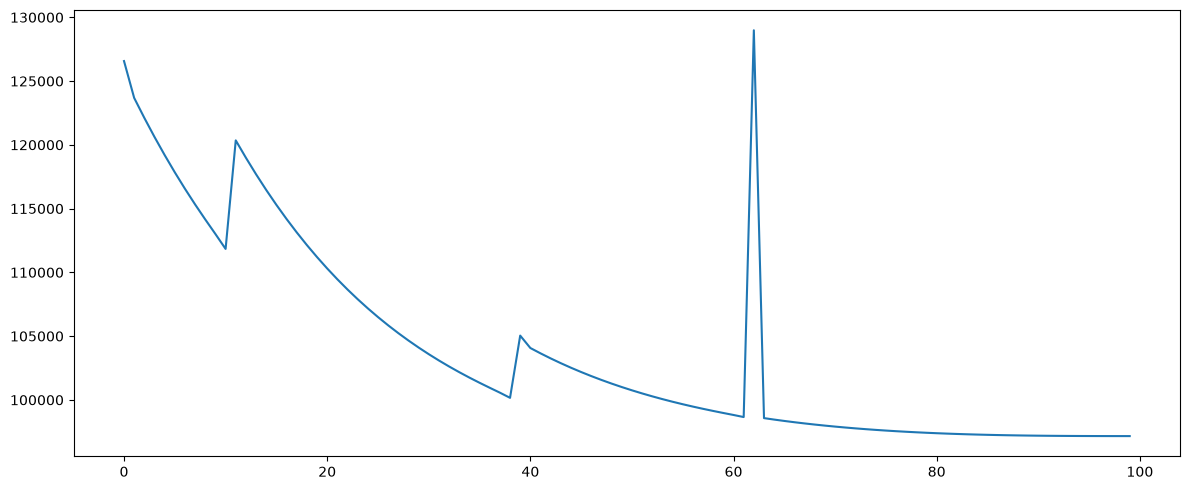

In [63]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 1, figsize=(12, 5))

axs.plot(range(EPOCHS), losses)

fig.tight_layout()
plt.show()

## Inference

In [64]:
def infer(P: dict, X: np.ndarray):
    batch_size, T = X.shape
    Ht = np.zeros((batch_size, H))

    outs = []
    for t in range(T):
        X_t = X[:, t].reshape(-1, D)
        Hprev = Ht
        Ht = compute_H(P, X_t, Hprev)
        out = compute_output(P, Ht)
        
        outs.append(out)
        
    outs = np.array(outs).reshape(T, batch_size)
    return outs

In [65]:
input = X[0, :].reshape(1, -1)
expected = Y[0, -1].reshape(-1, 1)


outs = infer(P, input)


print(f'input={input}')
print(f'expected={expected}')
print(f'prediction={outs[-1]}')

print('---------------------')
for e, o in zip(Y[0], outs):
    print(f'exp={e}, out={o}')

input=[[1 1 2 3]]
expected=[[5]]
prediction=[53.0607366]
---------------------
exp=1, out=[53.03791035]
exp=2, out=[53.03194053]
exp=3, out=[53.05971961]
exp=5, out=[53.0607366]
